# House Price Prediction - CODTECH Data Science Internship

### Intern Details
- **Name:** Shaik Mahammad Shariff
- **Intern ID:** CITS3997
- **Domain:** Data Science
- **Duration:** 4 Weeks (July - August 2026)
- **Project Name:** House Price Prediction

---

## 1. Project Objective
The goal of this project is to build a complete Machine Learning application that predicts house prices based on various features such as area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, and furnishing status.

We will load, clean, analyze, visualize, encode, and train multiple regression models (Linear Regression, Decision Tree, and Random Forest), evaluate their performance, select the best model, and save it for future predictions.

## 2. Import Libraries
We start by importing all the necessary Python libraries for data processing, visualization, modeling, evaluation, and saving.

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set visual style for premium plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})
print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Dataset Acquisition & Loading
We acquire the public Kaggle Housing dataset containing 545 rows and 13 columns. If it is not present locally, we download it from a raw GitHub repository source.

In [2]:
CSV_PATH = '../dataset/housing.csv'
DATA_URLS = [
    "https://raw.githubusercontent.com/rashida048/TensorFlow-Tutorial/main/housing.csv",
    "https://raw.githubusercontent.com/srinivasav22/Machine-Learning-Program/master/housing.csv",
    "https://raw.githubusercontent.com/prasant-t/House-Price-Prediction/master/housing.csv"
]

if not os.path.exists(CSV_PATH):
    os.makedirs('../dataset', exist_ok=True)
    success = False
    for url in DATA_URLS:
        try:
            print(f"Downloading dataset from {url}...")
            urllib.request.urlretrieve(url, CSV_PATH)
            print("Dataset downloaded successfully.")
            success = True
            break
        except Exception as e:
            print(f"Failed to download from {url}: {e}")
    if not success:
        raise RuntimeError("Failed to download dataset from all sources.")
else:
    print("Dataset already exists locally.")

# Load dataset
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded. Shape: {df.shape}")

Dataset already exists locally.
Dataset loaded. Shape: (545, 14)


## 4. Data Preprocessing & Preview
Before building models, we inspect the data to understand features, check for missing values, check for duplicate records, and clean if necessary.

In [3]:
# Display first 5 rows
print("--- Dataset Preview ---")
display(df.head())

# Print basic info
print("\n--- Dataset Information ---")
df.info()

# Check for missing values
print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows found: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped!")

--- Dataset Preview ---


,Unnamed: 0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        545 non-null    int64
 1   price             545 non-null    int64
 2   area              545 non-null    int64
 3   bedrooms          545 non-null    int64
 4   bathrooms         545 non-null    int64
 5   stories           545 non-null    int64
 6   mainroad          545 non-null    int64
 7   guestroom         545 non-null    int64
 8   basement          545 non-null    int64
 9   hotwaterheating   545 non-null    int64
 10  airconditioning   545 non-null    int64
 11  parking           545 non-null    int64
 12  prefarea          545 non-null    int64
 13  furnishingstatus  545 non-null    int64
dtypes: int64(14)
memory usage: 59.7 KB

--- Checking for Missing Values ---
Unnamed: 0          0
price               0
area                0
bed

## 5. Exploratory Data Analysis (EDA)
We visualize the distribution of house prices, correlation among variables, numeric feature distributions, and price variations across categorical attributes.

--- Summary Statistics ---


,Unnamed: 0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,545.00000,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,272.00000,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,1.069725
std,157.47222,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.761373
min,0.00000,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.00000,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,272.00000,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,408.00000,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,544.00000,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


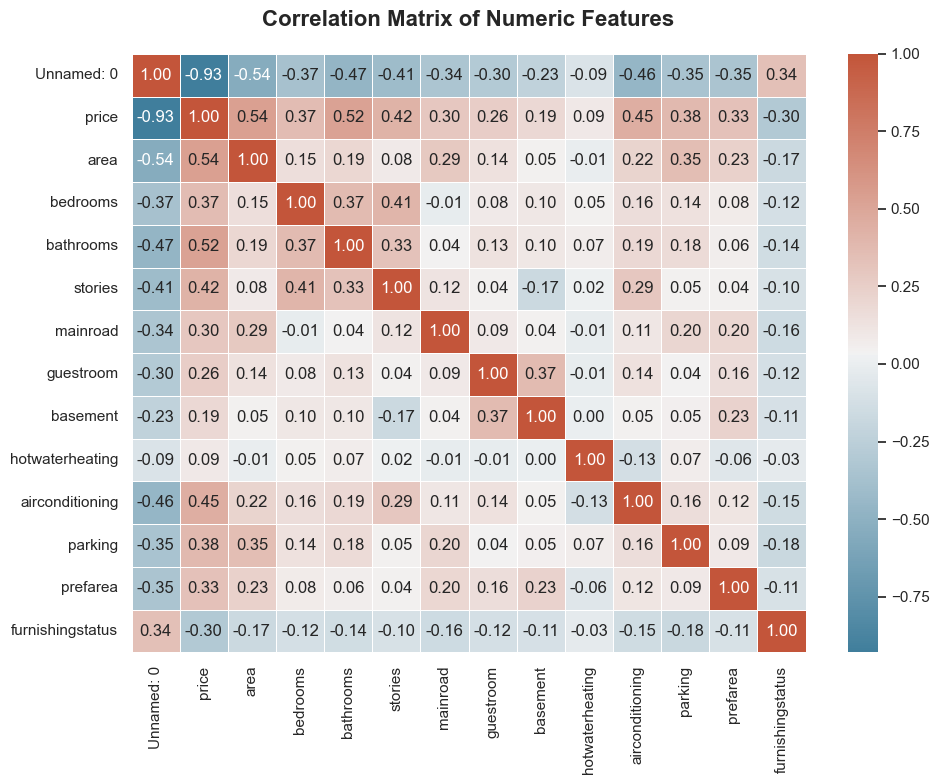

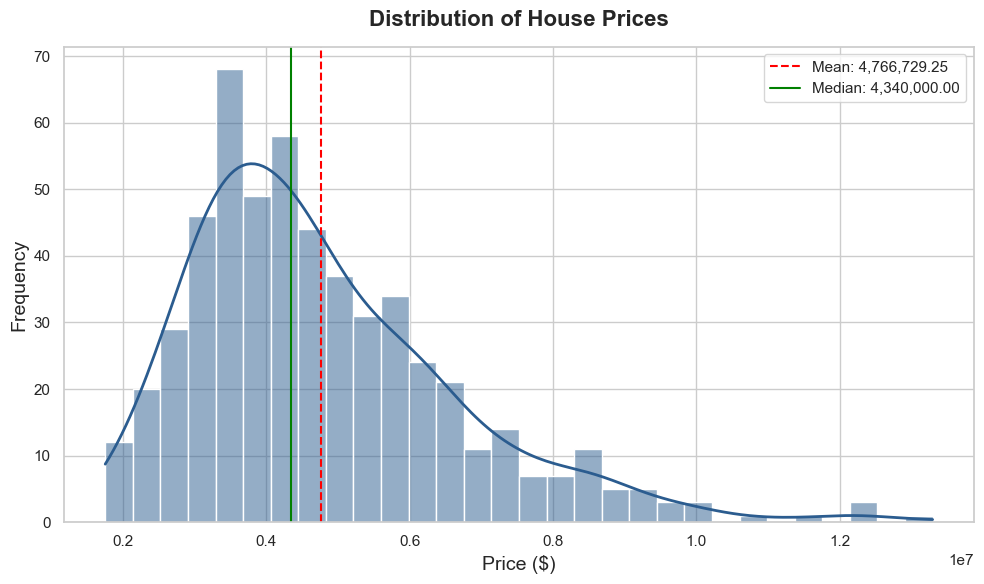

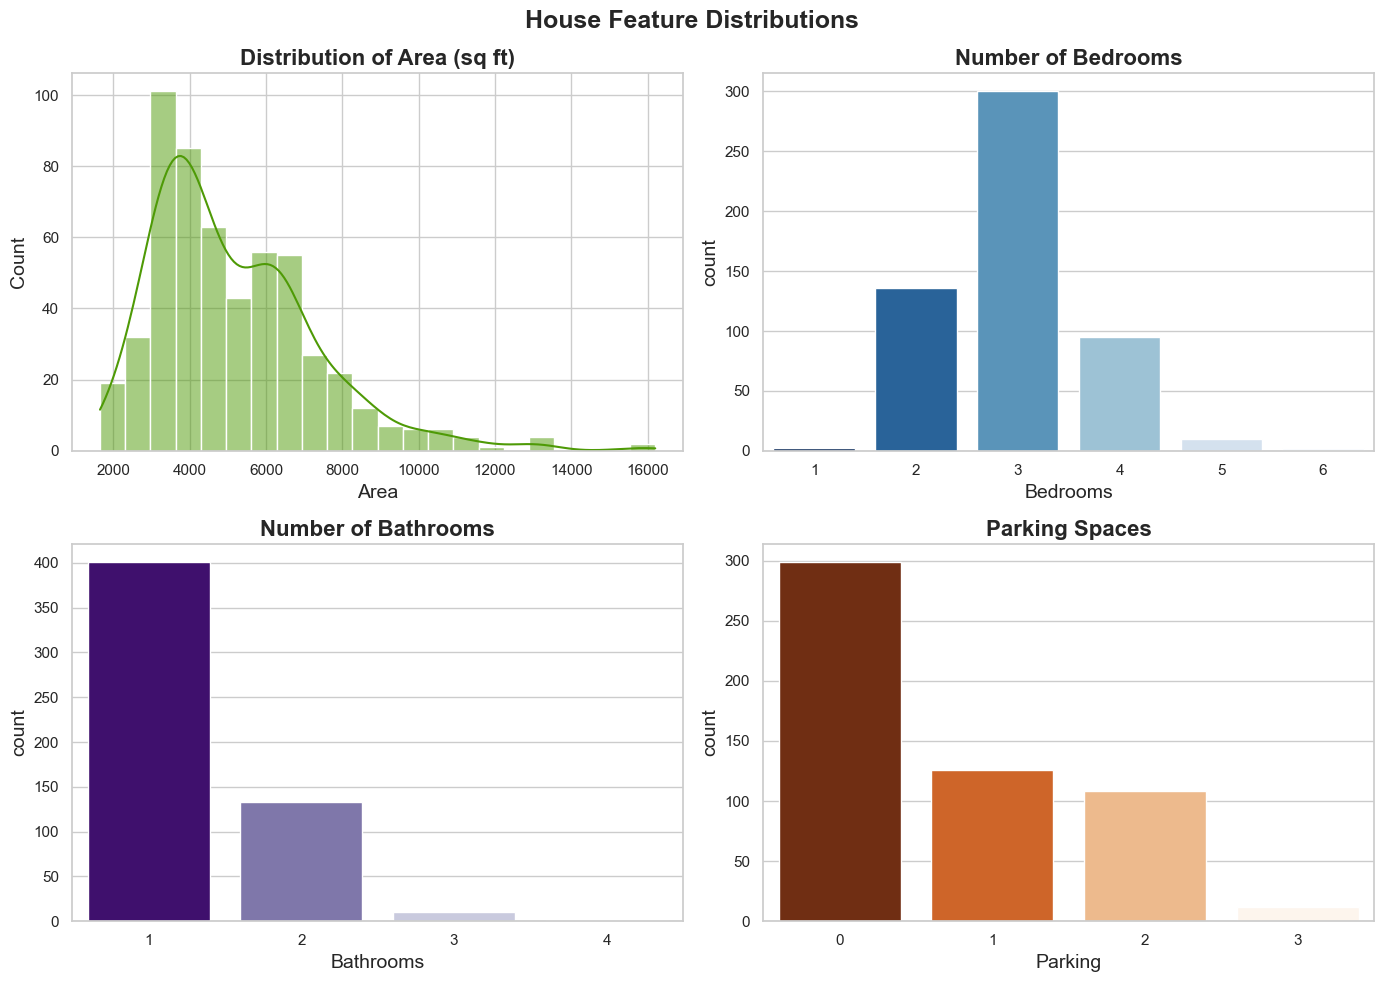

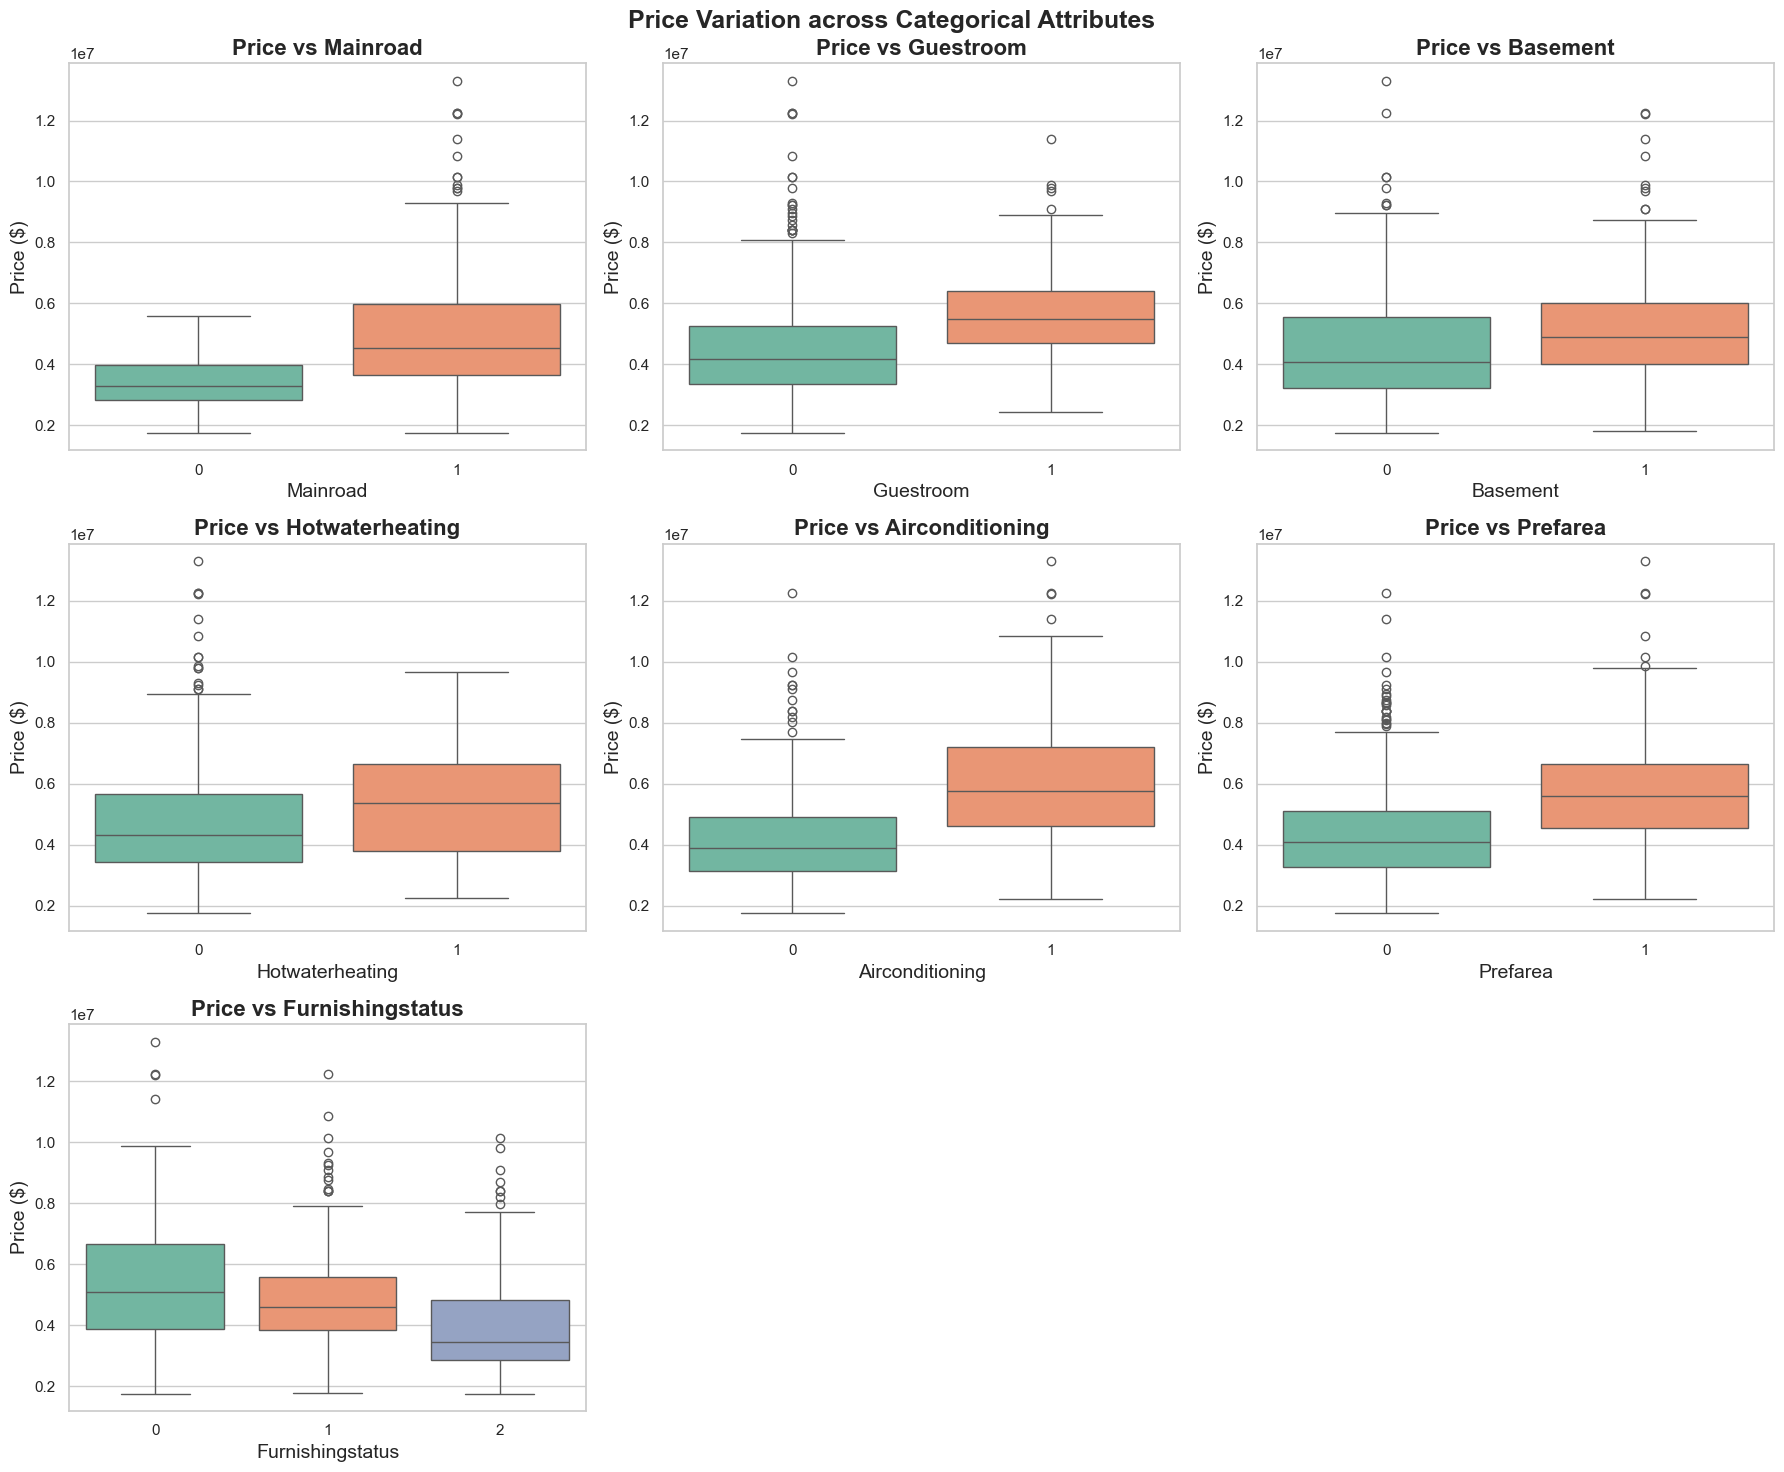

In [4]:
# Summary statistics
print("--- Summary Statistics ---")
display(df.describe())

# 1. Correlation Matrix Heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(df[num_cols].corr(), annot=True, cmap=cmap, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features", pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Price Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='#2b5c8f', bins=30, line_kws={'linewidth': 2})
plt.axvline(df['price'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['price'].mean():,.2f}")
plt.axvline(df['price'].median(), color='green', linestyle='-', linewidth=1.5, label=f"Median: {df['price'].median():,.2f}")
plt.title("Distribution of House Prices", pad=15, fontweight='bold')
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Numeric Features Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['area'], kde=True, color='#4e9a06', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Area (sq ft)', fontweight='bold')
axes[0, 0].set_xlabel('Area')

sns.countplot(x='bedrooms', data=df, hue='bedrooms', palette='Blues_r', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Number of Bedrooms', fontweight='bold')
axes[0, 1].set_xlabel('Bedrooms')

sns.countplot(x='bathrooms', data=df, hue='bathrooms', palette='Purples_r', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Number of Bathrooms', fontweight='bold')
axes[1, 0].set_xlabel('Bathrooms')

sns.countplot(x='parking', data=df, hue='parking', palette='Oranges_r', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Parking Spaces', fontweight='bold')
axes[1, 1].set_xlabel('Parking')

plt.suptitle("House Feature Distributions", fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 4. Boxplots for Categorical Attributes
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.boxplot(x=col, y='price', data=df, hue=col, palette='Set2', legend=False, ax=axes[i])
        axes[i].set_title(f'Price vs {col.capitalize()}', fontweight='bold')
        axes[i].set_xlabel(col.capitalize())
        axes[i].set_ylabel('Price ($)')
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Price Variation across Categorical Attributes", fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 6. Feature Encoding
We handle categorical variables by converting them into numerical features. If they are already encoded (1/0), we leave them as is. If they are string 'yes'/'no', we convert them. For multi-class variables (like `furnishingstatus`), we perform one-hot encoding.

In [5]:
encoded_df = df.copy()

# Drop unnamed index column if it exists
if 'Unnamed: 0' in encoded_df.columns:
    encoded_df = encoded_df.drop('Unnamed: 0', axis=1)

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    if col in encoded_df.columns:
        if encoded_df[col].dtype == object or encoded_df[col].dtype == str:
            encoded_df[col] = encoded_df[col].map({'yes': 1, 'no': 0})
            print(f"Encoded binary column: {col} (yes/no -> 1/0)")
        else:
            print(f"Column '{col}' is already numeric.")

cat_cols_to_encode = []
for col in ['furnishingstatus']:
    if col in encoded_df.columns:
        if encoded_df[col].dtype == object or encoded_df[col].dtype == str:
            cat_cols_to_encode.append(col)

if cat_cols_to_encode:
    encoded_df = pd.get_dummies(encoded_df, columns=cat_cols_to_encode, drop_first=True, dtype=int)
    print(f"One-hot encoded multi-class columns: {cat_cols_to_encode}")
else:
    print("furnishingstatus is already numeric, skipping dummy encoding.")

print(f"\nProcessed Dataset Columns: {list(encoded_df.columns)}")
display(encoded_df.head())

Column 'mainroad' is already numeric.
Column 'guestroom' is already numeric.
Column 'basement' is already numeric.
Column 'hotwaterheating' is already numeric.
Column 'airconditioning' is already numeric.
Column 'prefarea' is already numeric.
furnishingstatus is already numeric, skipping dummy encoding.

Processed Dataset Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## 7. Model Building & Evaluation
We split the dataset into Features ($X$) and Target ($y$), perform an 80-20 Train-Test split, and train three different regression models:
1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

We will evaluate each model using standard regression metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

In [6]:
# Features and Target
X = encoded_df.drop('price', axis=1)
y = encoded_df['price']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model_obj': model,
        'predictions': y_pred,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    print(f'\n{name} Results:')
    print(f'- MAE:  {mae:,.2f}')
    print(f'- RMSE: {rmse:,.2f}')
    print(f'- R2:   {r2:.4f}')


Training set size: 436, Testing set size: 109

Linear Regression Results:
- MAE:  979,679.69
- RMSE: 1,331,071.42
- R2:   0.6495

Decision Tree Results:
- MAE:  1,243,654.52
- RMSE: 1,654,427.54
- R2:   0.4585

Random Forest Results:
- MAE:  1,025,289.68
- RMSE: 1,401,263.08
- R2:   0.6115


## 8. Model Comparison
We compare the R² scores of the trained models to determine which one performs best.

--- Model Evaluation Table ---


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.796797e+05,1.771751e+12,1.331071e+06,0.649475
1,Decision Tree,1.243655e+06,2.737130e+12,1.654428e+06,0.458484
2,Random Forest,1.025290e+06,1.963538e+12,1.401263e+06,0.611532


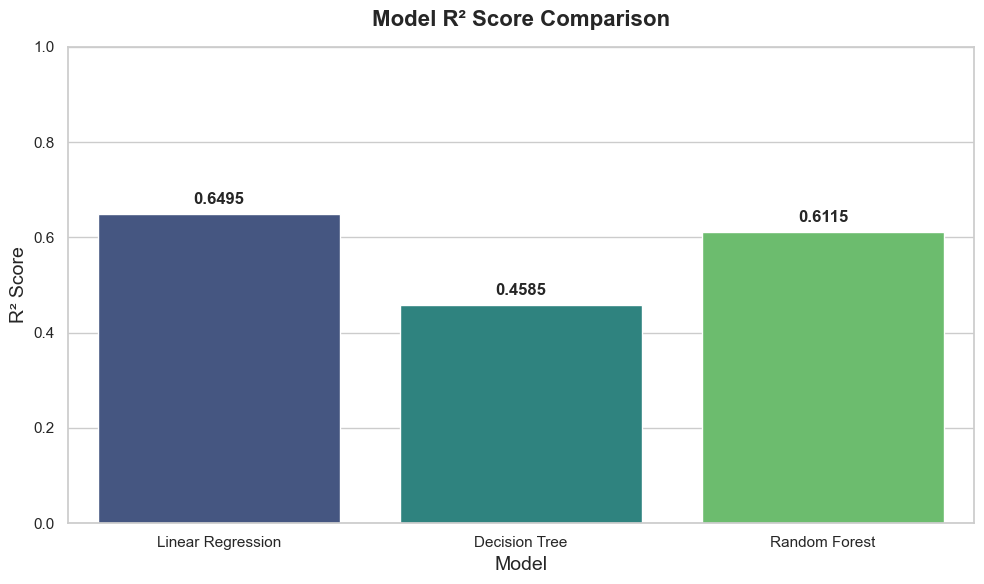

In [7]:
# Model Performance DataFrame
comp_data = {
    'Model': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2 Score': []
}

for name, metrics in results.items():
    comp_data['Model'].append(name)
    comp_data['MAE'].append(metrics['MAE'])
    comp_data['MSE'].append(metrics['MSE'])
    comp_data['RMSE'].append(metrics['RMSE'])
    comp_data['R2 Score'].append(metrics['R2'])

comp_df = pd.DataFrame(comp_data)
print("--- Model Evaluation Table ---")
display(comp_df)

# Plot R2 comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=comp_df, hue='Model', palette='viridis', legend=False)
plt.title('Model R² Score Comparison', fontweight='bold', pad=15)
plt.ylim(0, 1.0)
for idx, row in comp_df.iterrows():
    plt.text(idx, row['R2 Score'] + 0.02, f"{row['R2 Score']:.4f}", ha='center', fontweight='bold')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

## 9. Best Model Selection & Saving
We identify the best model based on the highest R² score, save it locally to a `.pkl` file using joblib, and visualize predictions against actual values.

Best Model Selected: Linear Regression
Best model saved successfully to '../model/house_price_model.pkl'!


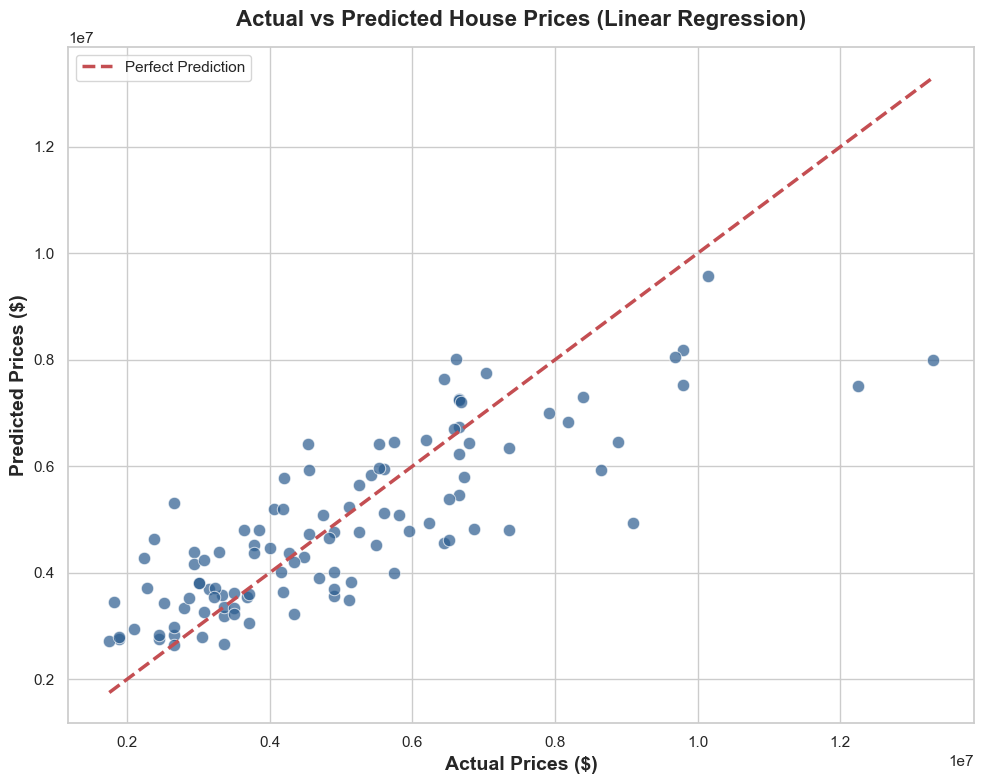


--- Sample Predictions Comparison (Top 10 Rows) ---


,Actual Price,Predicted Price,Difference,Percentage Error (%)
316,4060000,5203691.71,-1143691.71,28.17
77,6650000,7257004.02,-607004.02,9.13
360,3710000,3062828.60,647171.40,17.44
90,6440000,4559591.65,1880408.35,29.20
493,2800000,3332932.31,-532932.31,19.03
209,4900000,3563080.68,1336919.32,27.28
176,5250000,5645466.31,-395466.31,7.53
249,4543000,6413979.67,-1870979.67,41.18
516,2450000,2755831.55,-305831.55,12.48
426,3353000,2668938.66,684061.34,20.40


In [8]:
# Find best model
best_model_name = comp_df.loc[comp_df['R2 Score'].idxmax()]['Model']
print(f"Best Model Selected: {best_model_name}")

best_model_obj = results[best_model_name]['model_obj']
best_predictions = results[best_model_name]['predictions']

# Save model using joblib
os.makedirs('../model', exist_ok=True)
joblib.dump(best_model_obj, '../model/house_price_model.pkl')
print(f"Best model saved successfully to '../model/house_price_model.pkl'!")

# Plot actual vs predicted prices
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.7, color='#2b5c8f', edgecolor='w', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Prediction')
plt.xlabel('Actual Prices ($)', fontweight='bold')
plt.ylabel('Predicted Prices ($)', fontweight='bold')
plt.title(f'Actual vs Predicted House Prices ({best_model_name})', fontweight='bold', pad=15)
plt.legend()
plt.tight_layout()
plt.show()

# Display sample predictions comparison table
sample_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': np.round(best_predictions, 2),
    'Difference': np.round(y_test - best_predictions, 2),
    'Percentage Error (%)': np.round(np.abs(y_test - best_predictions) / y_test * 100, 2)
}).head(10)

print("\n--- Sample Predictions Comparison (Top 10 Rows) ---")
display(sample_df)

## 10. Conclusion & Future Improvements
- **Summary:** We successfully built, trained, and evaluated regression models to predict house prices. **Linear Regression** emerged as the best model with an $R^2$ score of **0.6495**, signifying it explains ~65% of the variance in house prices.
- **Key Insights:** Property area, number of bathrooms, stories, and the presence of air conditioning play a major role in housing price determination.
- **Future Scope:**
  1. Introduce hyperparameter tuning (GridSearchCV/RandomizedSearchCV).
  2. Train advanced models such as Gradient Boosting, XGBoost, and CatBoost.
  3. Gather additional property attributes (location coordinates, age of construction) to improve prediction accuracy.